In [1]:
import numpy as np
from tensorflow import keras
print (keras.__version__)

2.10.0


In [3]:
from keras.datasets import mnist

#We import data into variables and check their shape.

(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


In [19]:
y_train.shape

(60000,)

In [20]:
y_train[0:10]

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4], dtype=uint8)

In [21]:
#we create new variables that contain only zeros and ones.

x_train_new, y_train_new = x_train[(y_train==0) | (y_train==1)], y_train[(y_train==0) | (y_train==1)]

#Let’s check the shape of the new variables.

x_train_new.shape

(12665, 28, 28)

In [22]:
y_train[0:10]

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4], dtype=uint8)

In [23]:
#we need to flatten data into two dimensions only: index and flattened image data (28 * 28 = 784).

x_train_final = x_train_new.reshape((-1, 784))
x_train_final.shape

(12665, 784)

In [24]:
#A similar sequence of operations we perform for the test set.

x_test_new, y_test_new = x_test[(y_test==0) | (y_test==1)], y_test[(y_test==0) | (y_test==1)]
x_test_new.shape

(2115, 28, 28)

In [25]:
x_test_final = x_test_new.reshape((-1, 784))


In [26]:
#The last element of data preprocessing is their normalization.

x_train_final = x_train_final / 255
x_test_final = x_test_final / 255

In [27]:
model = keras.Sequential(keras.layers.Dense(1, input_shape=(784,), activation='sigmoid'))

In [28]:
model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['binary_accuracy'])

In [29]:
model.fit(
  x=x_train_final,
  y=y_train_new,
  shuffle=True,
  epochs=10,
  batch_size=16
)

Epoch 1/10
792/792 [==============================] - 1s 1ms/step - loss: 0.0750 - binary_accuracy: 0.9902
Epoch 2/10
792/792 [==============================] - 1s 1ms/step - loss: 0.0205 - binary_accuracy: 0.9976
Epoch 3/10
792/792 [==============================] - 1s 1ms/step - loss: 0.0149 - binary_accuracy: 0.9976
Epoch 4/10
792/792 [==============================] - 1s 1ms/step - loss: 0.0123 - binary_accuracy: 0.9979
Epoch 5/10
792/792 [==============================] - 1s 1ms/step - loss: 0.0108 - binary_accuracy: 0.9979
Epoch 6/10
792/792 [==============================] - 1s 1ms/step - loss: 0.0098 - binary_accuracy: 0.9981
Epoch 7/10
792/792 [==============================] - 1s 1ms/step - loss: 0.0090 - binary_accuracy: 0.9982
Epoch 8/10
792/792 [==============================] - 1s 1ms/step - loss: 0.0084 - binary_accuracy: 0.9984
Epoch 9/10
792/792 [==============================] - 1s 1ms/step - loss: 0.0079 - binary_accuracy: 0.9984
Epoch 10/10
792/792 [================

In [30]:
eval = model.evaluate(x=x_test_final, y=y_test_new)

67/67 [==============================] - 0s 1ms/step - loss: 0.0045 - binary_accuracy: 0.9995


In [1]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np


y_true = ["covid","covid", "covid", "covid", "covid", "non-covid","non-covid","non-covid","non-covid","non-covid"]
y_pred = ["covid","non-covid", "covid", "covid", "covid", "non-covid","non-covid","non-covid","covid","covid"]
y_true=np.array(y_true)
y_pred=np.array(y_pred)
cm=confusion_matrix(y_true, y_pred)
print(cm)
plt.imshow(cm, cmap='binary')
plt.show()


[[4 1]
 [2 3]]


<Figure size 640x480 with 1 Axes>

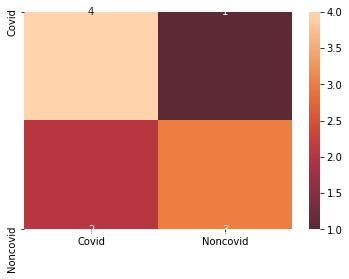

In [3]:
import pandas as pd
import seaborn as sn
cm=confusion_matrix(y_true, y_pred)
data=pd.DataFrame(cm,index=["Covid" , "Noncovid"] ,columns=["Covid" , "Noncovid"])
sn.heatmap(data,annot=True,center=0)